In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [4]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print(f"Logistic Regression accuracy: {logistic_accuracy:.2%}")

Logistic Regression accuracy: 96.67%


In [5]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_accuracy = accuracy_score(
    y_test,
    tree_pred
)

print(f"Decision Tree accuracy: {tree_accuracy:.2%}")

Decision Tree accuracy: 93.33%


In [6]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print(f"KNN accuracy: {knn_accuracy:.2%}")

KNN accuracy: 100.00%


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(f"Random Forest accuracy: {rf_accuracy:.2%}")

Random Forest accuracy: 90.00%


In [8]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        knn_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.966667
1,Decision Tree,0.933333
2,KNN,1.000000
3,Random Forest,0.900000


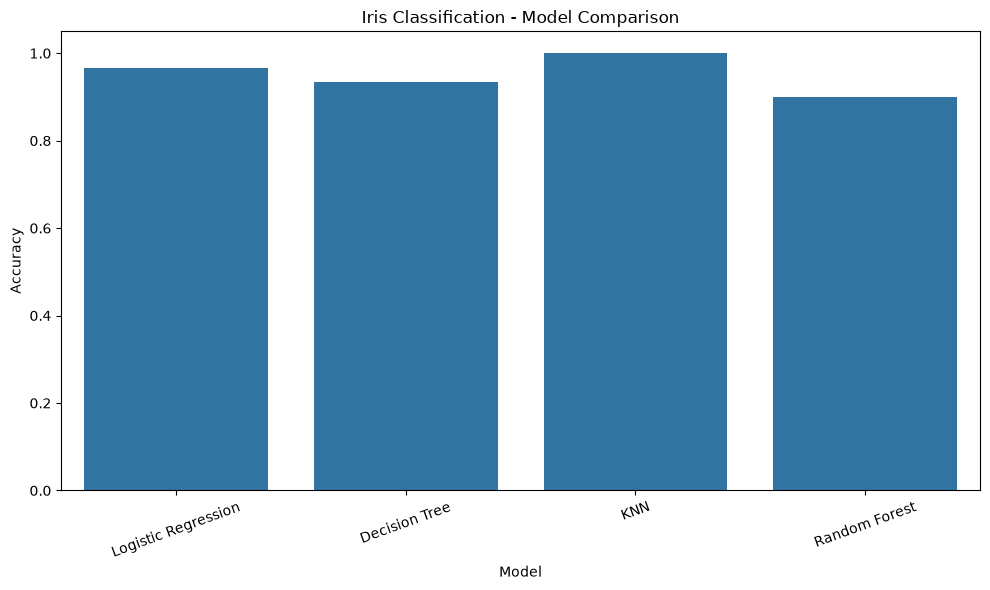

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Iris Classification - Model Comparison")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [10]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



Precision : Parmi les fleurs prédites comme appartenant à une classe, combien étaient réellement dans cette classe 

Recall : Parmi toutes les fleurs réellement dans cette classe, combien avons-nous correctement identifiées 

F1-score : Compromis entre precision et recall.

In [11]:
feature_importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


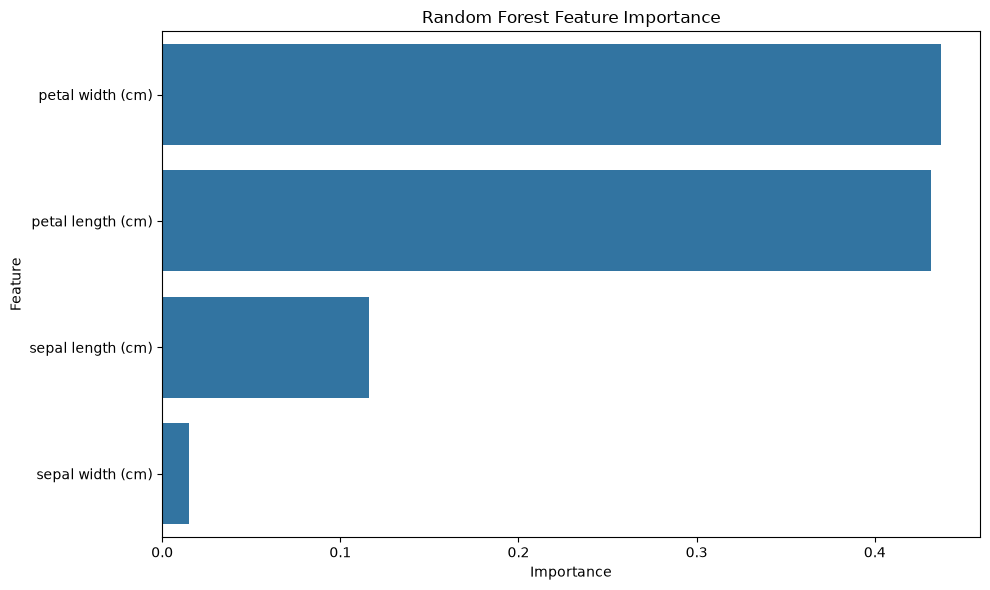

In [12]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.tight_layout()

plt.show()

In [13]:
plt.savefig(
    "../results/figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [14]:
plt.savefig(
    "../results/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

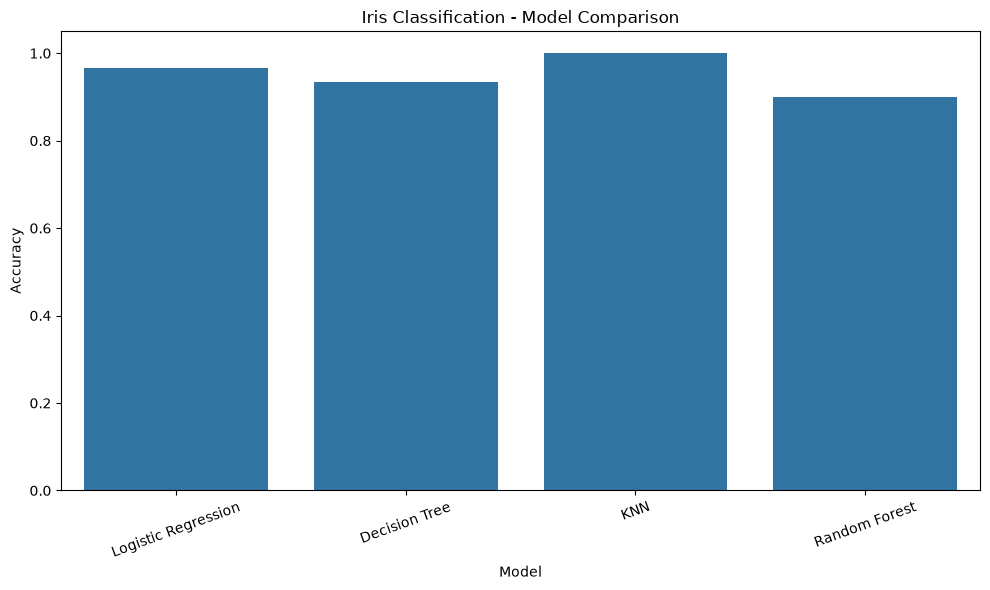

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Iris Classification - Model Comparison")
plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "../results/figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

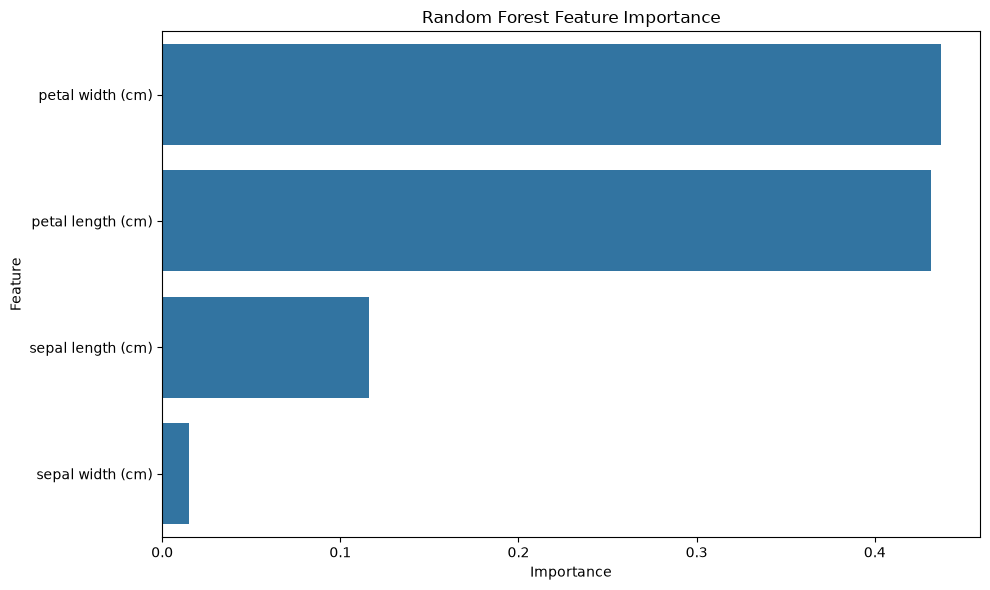

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../results/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [19]:
print(results)

                 Model  Accuracy
0  Logistic Regression  0.966667
1        Decision Tree  0.933333
2                  KNN  1.000000
3        Random Forest  0.900000


In [20]:
print(feature_importance)

             Feature  Importance
3   petal width (cm)    0.437185
2  petal length (cm)    0.431466
0  sepal length (cm)    0.116349
1   sepal width (cm)    0.015000


                DATASET
                   │
                   ▼
             TRAIN / TEST
              │         │
              │         │
              ▼         ▼
       Cross-validation TEST
              │         │
              ▼         │
       Model selection  │
              │         │
              └────┬────┘
                   ▼
            Final evaluation
    le test set sert à faire l'évaluation finale
    la cross validation sert à évaluer la robustesse du modèle pendant le développement/comparaison.

In [24]:
from sklearn.model_selection import cross_val_score

In [25]:
logistic_cv = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Scores :", logistic_cv)
print("Moyenne :", logistic_cv.mean())
print("Écart-type :", logistic_cv.std())

Scores : [0.96666667 1.         0.93333333 0.96666667 1.        ]
Moyenne : 0.9733333333333334
Écart-type : 0.02494438257849294


In [26]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "KNN": knn_model,
    "Random Forest": rf_model
}

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df

,Model,Mean Accuracy,Std
0,Logistic Regression,0.973333,0.024944
1,Decision Tree,0.953333,0.033993
2,KNN,0.973333,0.024944
3,Random Forest,0.966667,0.021082


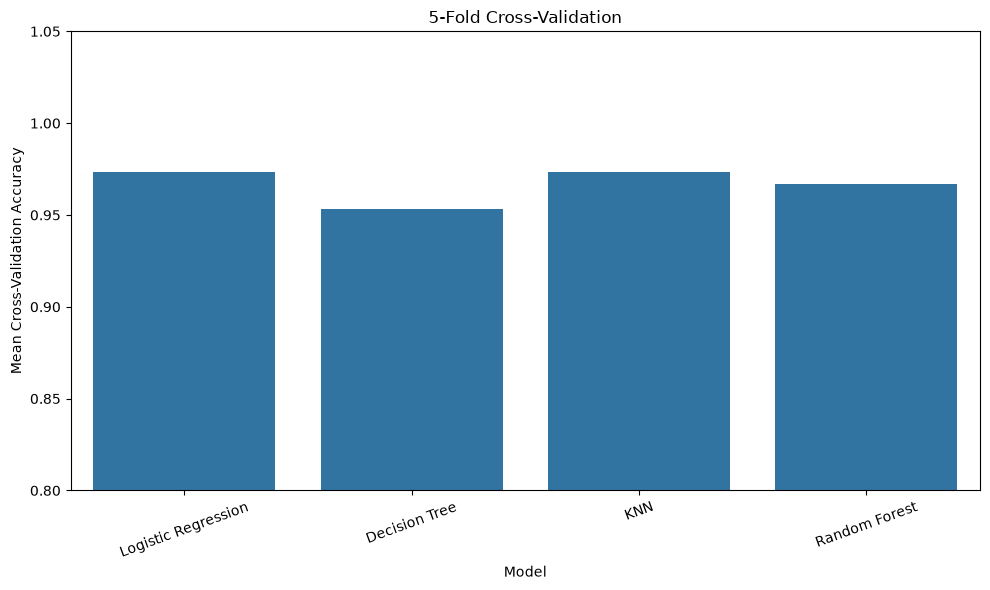

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_df,
    x="Model",
    y="Mean Accuracy"
)

plt.ylim(0.8, 1.05)
plt.ylabel("Mean Cross-Validation Accuracy")
plt.xlabel("Model")
plt.title("5-Fold Cross-Validation")

plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    "../results/figures/cross_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

Dataset
   ↓
Train/Test
   ↓
Pipeline
   ├── preprocessing
   ├── feature selection
   └── model

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

overfit_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

overfit_tree.fit(X_train, y_train)

train_pred = overfit_tree.predict(X_train)
test_pred = overfit_tree.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"Training accuracy: {train_accuracy:.2%}")
print(f"Testing accuracy:  {test_accuracy:.2%}")

Training accuracy: 100.00%
Testing accuracy:  93.33%


In [30]:
overfitting_results = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Accuracy": [train_accuracy, test_accuracy]
})

overfitting_results

,Dataset,Accuracy
0,Training,1.000000
1,Testing,0.933333


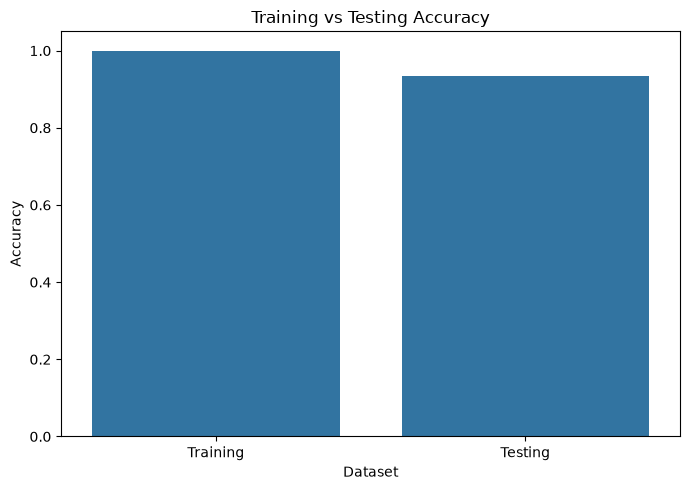

In [31]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=overfitting_results,
    x="Dataset",
    y="Accuracy"
)

plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")

plt.tight_layout()

plt.savefig(
    "../results/figures/overfitting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [32]:
depths = range(1, 11)

train_scores = []
test_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(
        model.score(X_train, y_train)
    )

    test_scores.append(
        model.score(X_test, y_test)
    )

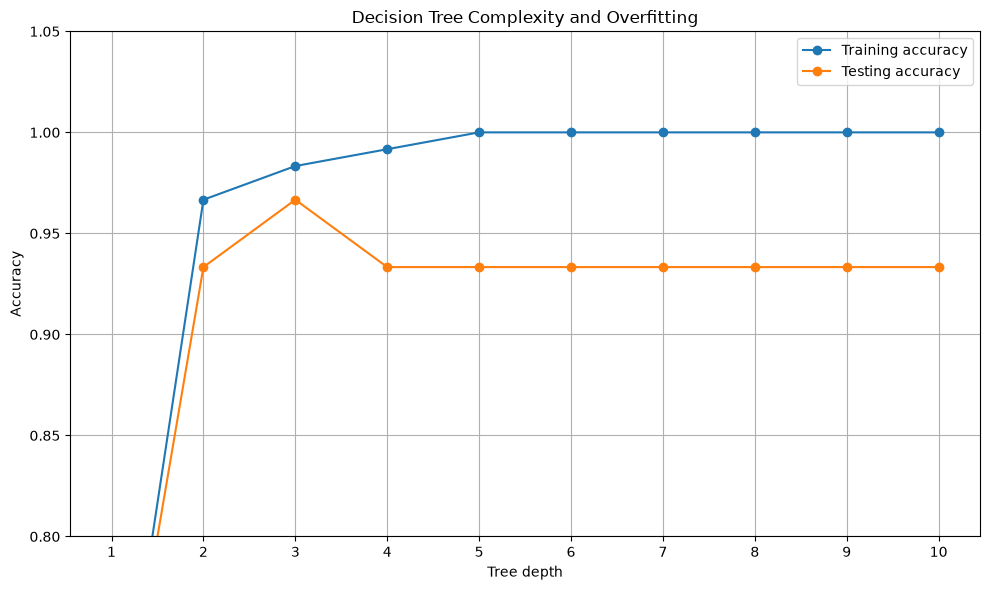

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_scores,
    marker="o",
    label="Training accuracy"
)

plt.plot(
    depths,
    test_scores,
    marker="o",
    label="Testing accuracy"
)

plt.xlabel("Tree depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Complexity and Overfitting")

plt.xticks(list(depths))
plt.ylim(0.8, 1.05)

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../results/figures/decision_tree_overfitting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()